## Encoding
### Opdracht

Zoals aan het begin van de cursus besproken gaat het project over handgeschreven nummers herekennen op een MysteryDevice met de volgende eigenschappen:

- Input scherm waarmee een nieuwe plaatje als ndarray aangemaakt kan worden door de gebruiker.
- Zeer beperkt RAM (256 KB)
- Beperkte opslag (1 MB voor 
programma + model)
- Geen GPU
- Embedded python


In [3]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
import sys
import math


In [4]:
(images, labels), (test_images, test_labels) = mnist.load_data()

In [5]:
def print_bytes_numpy(obj: any):
    """
    Print the amount of bytes used by an object
    """
    print(f"element size: {obj.nbytes * 8} bits")
    print(f"data structure size: {sys.getsizeof(obj) * 8} bits")

def print_size_builtin(obj: any):
    print(f"data structure size: {sys.getsizeof(obj) * 8} bits")

MysteryDevice opslaglimiet: 1 MB
Volledige MNIST dataset: 52 MB

Dus het opslaan van MNST voor training doeleinden zou niet werken. Maar in ons geval maakt het ook niet uit, want we kunnen onze AI methode op een PC trainen.

Echter, hebben we nog steeds een encoding van afbeeldingen nodig omdat de gebruiker wel een afbeelding invoert.

#### Hoe ziet de input eruit tijdens inference?

De gebruiker tekent op het touchscreen → dat moet naar 28×28 of een andere encoding worden gebracht.

#### Hoeveel RAM gebruikt die inputrepresentatie?

784 bytes (1 byte per pixel) -> heel laag
maar 32‑bits floats → 784 × 4 = 3 KB -> al een stuk hoger

Ontwerp een encoding van een MNIST plaatje die zo min mogelijk geheugen nodig heeft op het MysteryDevice om je Decision Tree uit de vorige opdracht te draaien op 1 sample. 

Mogelijk heb je al wat gedaan in de vorige stap, maar kijk of je het nog meer kan verbeteren.
Het moet:

- minder geheugen gebruiken
- minder rekenkracht nodig hebben
- toch informatie bewaren om cijfers te herkennen

Maak eventueel gebruik aan de volgende onderweren, maar ga vooral zelf experimenteren:
- binning
(“donker / medium / licht” → 3 waarden)

- binary thresholding
(zwart/wit → 1 bit per pixel)

- downscaling
(28×28 → 14×14 → 196 features)

- flattening
(784 → 784 vector)

- quantization
(8-bit → 4-bit → 2-bit per pixel)

- feature extraction
(bijv. “hoeveel inkt zit links/rechts/boven/onder?”)
- sparse encoding
(alleen niet‑nul pixels bewaren)

- Ga je normaliseren? Hoe?
- Ga je flattenen of 2D laten staan?
- Ga je binning toepassen op pixelwaarden?
- Ga je ordinale encoding toepassen op pixelintensiteiten?
- Ga je pixelwaarden reduceren (bijv. “donker, medium, licht”)?
- Ga je één pixel gebruiken, of alle 784?

**Ga ook een eigen “encoding” bedenken!**

__antwoord__\
\
Als eerst maak ik een controle groep. Dus helemaal geen encoding.\
Daarna ga ik de volgende encoding technieken uitproberen.
- Binning middels een boolean
- Binning middels bits
- Binnen middels bits maar dan via numpy omzetten naar binair
- Resolutie omlaag brengen
- Tellen van kleurveranderingen

## No Encoding

In [6]:
def no_encode(img):
    encoded = img  # vervang dit
    return encoded

In [7]:
print_bytes_numpy(no_encode(images[0]))

element size: 6272 bits
data structure size: 1024 bits


## Binning met bool
Er is geen effect op de grote.


In [8]:
def bin_encode(img):
    encoded = np.astype(img, "bool")
    return encoded

In [9]:
print_bytes_numpy(bin_encode(images[0]))

element size: 6272 bits
data structure size: 7296 bits


# Binair Binnen

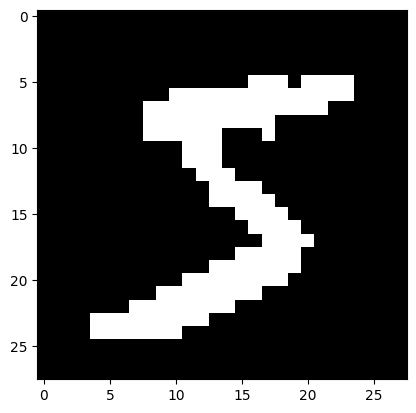

In [10]:
def binary_encode(image):
    bin_image = bytearray()

    binary_secion: str = ""
    for row in image: # write pixel data one by one
        for pixel in row:
            if pixel > 50:
                binary_secion += "1"
            else:
                binary_secion += "0"

            if len(binary_secion)  == 8:
                encoded_section = int(binary_secion, 2)
                bin_image.append(encoded_section)
                binary_secion = ""

    return bytes(bin_image)

def binary_decode(binary: bytes, size = 28):
    binaries = ""
    for byte in binary:
        binary_section = bin(byte)[2:].zfill(8)
        binaries += binary_section
    one_d_image = []
    for px in binaries:
        one_d_image.append(int(px) * 255)
    image = np.reshape(one_d_image, (size, size))

    return image


encoded = binary_encode(images[0])
decoded = binary_decode(encoded)
plt.imshow(decoded, cmap="grey")
plt.show()

In [11]:
print_size_builtin(encoded)



data structure size: 1048 bits


element size: 6272 bits
data structure size: 1024 bits
element size: 784 bits
data structure size: 1680 bits
element size: 6272 bits
data structure size: 1024 bits


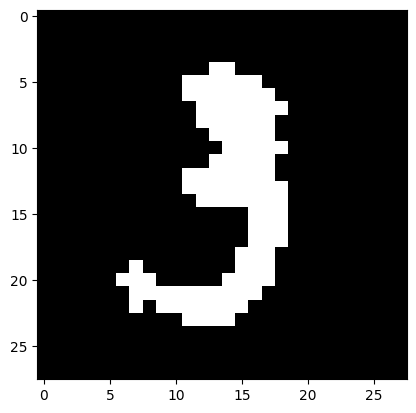

In [12]:
def bin_image(image, threshold = 122):
    """
    Turn an image into it's binned version with unit8's of values 1 and 0. threshold determines below what values a pixel is condicered empty (0)
    """
    size = len(image)
    binned_image = np.zeros((size,size), dtype="uint8")
    for y_i, y_val in enumerate(image):
        for x_i, x_val in enumerate(y_val):
            if x_val > threshold:
                binned_image[y_i, x_i] = 1
            else:
                binned_image[y_i, x_i] = 0
    return binned_image


def binary_encode_np(image):
    image = bin_image(image)
    return np.packbits(image)

def binary_decode_np(encoded_image):
    unpacked = np.unpackbits(encoded_image)
    size = int(math.sqrt(len(unpacked)))
    return unpacked[: size**2].reshape((size, size))



print_bytes_numpy(images[10])
print_bytes_numpy(binary_encode_np(images[10]))
repacked = binary_decode_np(binary_encode_np(images[10]))
print_bytes_numpy(repacked)

plt.imshow(repacked, cmap="grey")
plt.show()

# Compression

element size: 1568 bits
data structure size: 2592 bits


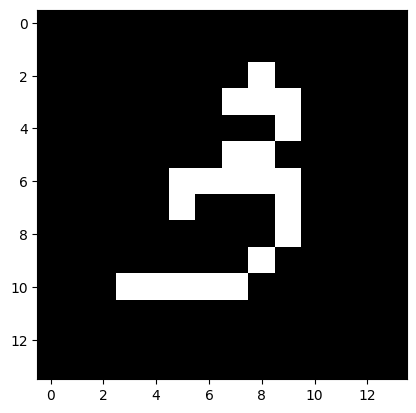

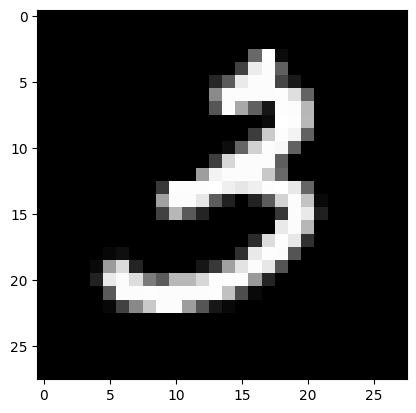

In [13]:
def compres_image(image, new_size = 14):
    """
    Reduce the resolution of an image
    """
    originial_size = len(image)
    step = originial_size / new_size
    steps = [s * step for s in range(new_size)]
    new_image = np.zeros((new_size, new_size), dtype="uint8")
    y_i = 0
    for block_y_start in steps:
        block_y_end = block_y_start + step
        x_i = 0
        for block_x_start in steps:
            block_x_end = block_x_start + step
            block = image[int(block_y_start) : int(block_y_end), int(block_x_start): int(block_x_end)]
            pixel_color = np.average(block)
            new_image[y_i, x_i] = pixel_color
            x_i += 1
        y_i += 1
    return new_image



img = compres_image(images[1551], 14)
print_bytes_numpy(img)
img = binary_encode_np(img)
img = binary_decode_np(img)
plt.imshow(img, cmap="grey")
plt.show()
plt.imshow(images[1551], cmap="grey")
plt.show()

# Counting changes

Bijhouden van een array waarin de verandering wordt weergegeven tussen zwart en wit

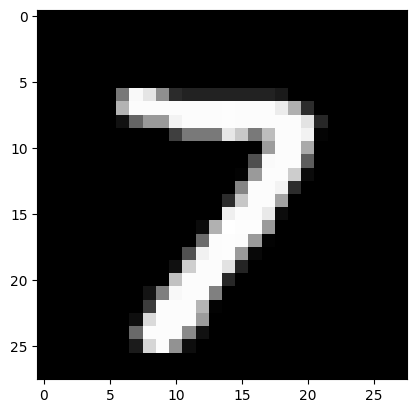

[174  13  15  15  13  16  16  12  23   4  23   5  22   6  22   5  22   5
  23   5  21   6  22   6  21   6  21   6  22   5  21   6  22   6  21   6
  22   6  22   5  72]
28
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 0 0 0 0]
 [0

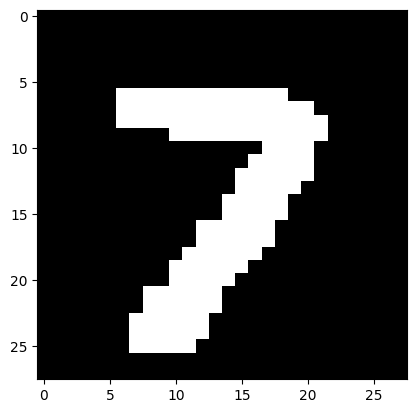

In [14]:
def encode_counting(image):
    result = np.zeros((0), dtype="uint8")
    length_of_color = 0
    is_white = image[0,0] != 0

    for y_i, row in enumerate(image):
        for x_i, pixel in enumerate(row):
            is_pixel_white = pixel != 0
            if (is_pixel_white == is_white):
                length_of_color += 1
            else:
                result = np.append(result, length_of_color)
                length_of_color = 1
                is_white = is_pixel_white
    result = np.append(result, length_of_color)

    return result


def decode_counting(encoded):
    result = np.zeros((0), dtype="uint8")
    is_white = False  # technical dept should be dynamic
    for section in encoded:
        result_section = np.full((section), int(is_white))
        is_white = not is_white
        result = np.concat((result, result_section))
    size = int(math.sqrt(len(result)))
    print(size)
    result = result[:size**2]
    result = result.reshape((size, size))
    return result


plt.imshow(images[4000], cmap="grey")
plt.show()
encoded = encode_counting(images[4000])
print(encoded)
decoded = decode_counting(encoded)
print(decoded)

plt.imshow(decoded, cmap="grey")
plt.show()

Beantwoord ook de volgende vragen:

- Hoeveel RAM kost één afbeelding?
- Hoeveel RAM kost 100 afbeeldingen?
- Hoe groot zou het model maximaal mogen zijn?
- Kun je de encoding verder comprimeren?
- Is er informatie verloren gegaan?
- Kun je nog steeds het cijfer herkennen?

# Ram kosten voor één afbeeldingen

empty array size: 72


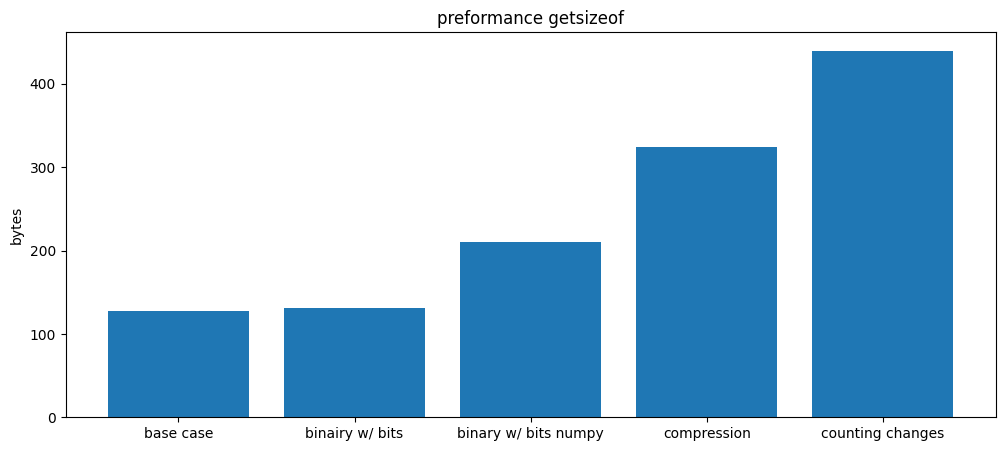

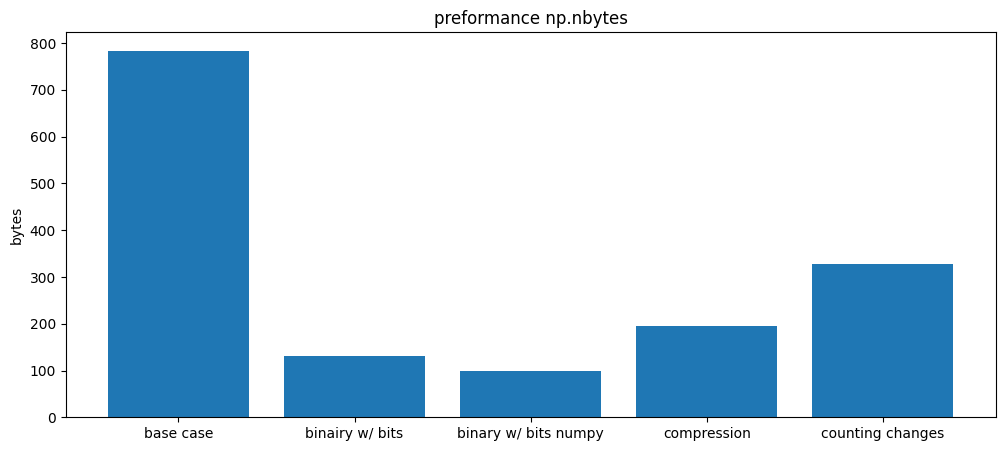

In [15]:
fig, ax = plt.subplots()

print("empty array size:", sys.getsizeof(np.array))

encoding_techique = ['base case',
                     'binairy w/ bits',
                     'binary w/ bits numpy',
                     "compression",
                     "counting changes"]
counts = [
    sys.getsizeof(images[40]),
    sys.getsizeof(binary_encode(images[40])),
    sys.getsizeof(binary_encode_np(images[40])),
    sys.getsizeof(compres_image(images[40])),
    sys.getsizeof(encode_counting(images[40]))]

ax.bar(encoding_techique, counts)

ax.set_ylabel('bytes')
ax.set_title('preformance getsizeof')
fig.set_size_inches((12, 5))



fig, ax = plt.subplots()

encoding_techique = ['base case',
                     'binairy w/ bits',
                     'binary w/ bits numpy',
                     "compression",
                     "counting changes"]
counts = [
    images[40].nbytes,
    sys.getsizeof(binary_encode(images[40])),
    binary_encode_np(images[40]).nbytes,
    compres_image(images[40]).nbytes,
    encode_counting(images[40]).nbytes]

ax.bar(encoding_techique, counts)

ax.set_ylabel('bytes')
ax.set_title('preformance np.nbytes')
fig.set_size_inches((12, 5))

plt.show()

# Ram kosten voor honderd afbeeldingen

Gezien er geen optimalisering is tussen verschillede afbeeldingen zijn de ram kosten als volgt te berekenen:\
ram_kosten = kosten_opslag_enkele_afbeelding * 100 + overhead_van_datastructuur_waarin_afbeeldingen_worden_opgeslagen

# Verdere optimalisering

Om de opslag grote nog verder te verkleinen kunnen verschillende technieken gecombineerd worden. Bijvoorbeeld lichte compression in combinatie met binair binnen.

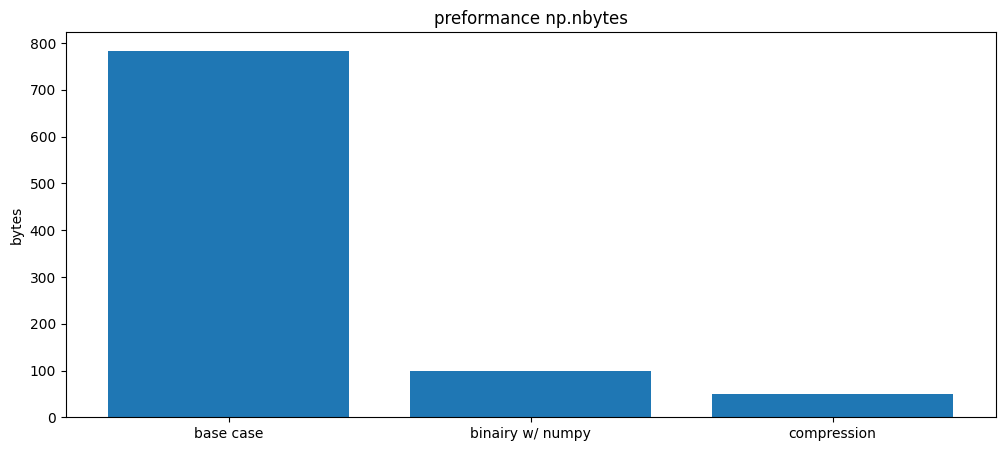

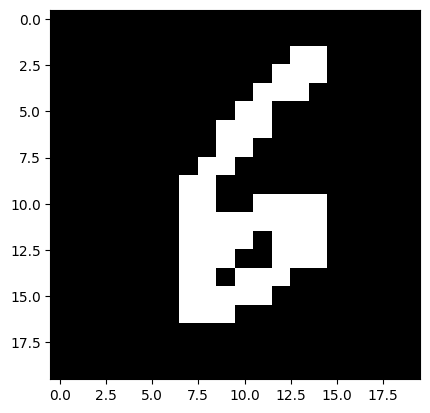

In [16]:
fig, ax = plt.subplots()

image = images[4112]
very_encoded_image = binary_encode_np(compres_image(image, 20))

encoding_techique = ['base case',
                     'binairy w/ numpy',
                     "compression"]
counts = [
    image.nbytes,
    binary_encode_np(image).nbytes,
    very_encoded_image.nbytes]

ax.bar(encoding_techique, counts)

ax.set_ylabel('bytes')
ax.set_title('preformance np.nbytes')
fig.set_size_inches((12, 5))

plt.show()

plt.imshow(binary_decode_np(very_encoded_image), cmap="grey")
plt.show()

# Herkenbaarheid

Voor het blote oog zijn de cijfers nog te herkennen, maar hoe gaat de computer hier mee om?
Er is in iedergeval informatie verloren gegaan. Namelijk de zachtere kleurverlopen. Ook is de resolutie naar beneden gebracht.\

## Alogritme
Voor de herkenning wordt gebruikt gemaakt van het k-means herkennings alogritme dat in week 5 is ontwikkeld.

In [ ]:
from k_means_methods import *;

def accuracy_after_compression(compression_method, prototypes: int, train_images, train_labels, test_images, test_labels):

    train_images = [normalize_and_vectorize_image(compression_method(img)) for img in train_images]
    test_images = [normalize_and_vectorize_image(compression_method(img)) for img in test_images]

    base_prototypes = make_prototype(train_images, train_labels, prototypes)

    determine_accuracy(base_prototypes, test_images, test_labels)

print("baseline")
accuracy_after_compression(
    lambda x: x,
    5,
    images,
    labels,
    test_images,
    test_labels
)

print("numpy binary")
accuracy_after_compression(
    lambda img: binary_decode_np(binary_encode_np(img)),
    5,
    images,
    labels,
    test_images,
    test_labels
)

print("compressed 24 px")
accuracy_after_compression(
    lambda img: compres_image(img, 24),
    3,
    images,
    labels,
    test_images,
    test_labels
)

print("compressed 20 px")
accuracy_after_compression(
    lambda img: compres_image(img, 20),
    3,
    images,
    labels,
    test_images,
    test_labels
)

print("compressed 14 px")
accuracy_after_compression(
    lambda img: compres_image(img, 14),
    3,
    images,
    labels,
    test_images,
    test_labels
)

print("compressed 14 px + binary")
accuracy_after_compression(
    lambda img: binary_decode_np(binary_encode_np(compres_image(img, 14))),
    3,
    images,
    labels,
    test_images,
    test_labels
)


baseline
finished for number 0
finished for number 1
finished for number 2
finished for number 3
finished for number 4
finished for number 5
finished for number 6
finished for number 7
finished for number 8
finished for number 9
finished computing prototypes
misses 1132
accuracy 88.68 %
{0: 47, 1: 13, 2: 124, 3: 146, 4: 175, 5: 165, 6: 56, 7: 101, 8: 136, 9: 169}
numpy binary
finished for number 0
finished for number 1
finished for number 2
finished for number 3
finished for number 4
finished for number 5
finished for number 6
finished for number 7
finished for number 8
finished for number 9
finished computing prototypes
misses 1172
accuracy 88.28 %
{0: 69, 1: 12, 2: 138, 3: 130, 4: 154, 5: 126, 6: 52, 7: 189, 8: 155, 9: 147}
compressed 24 px
finished for number 0
finished for number 1
finished for number 2
finished for number 3
finished for number 4
finished for number 5
finished for number 6
finished for number 7
finished for number 8
finished for number 9
finished computing prototyp

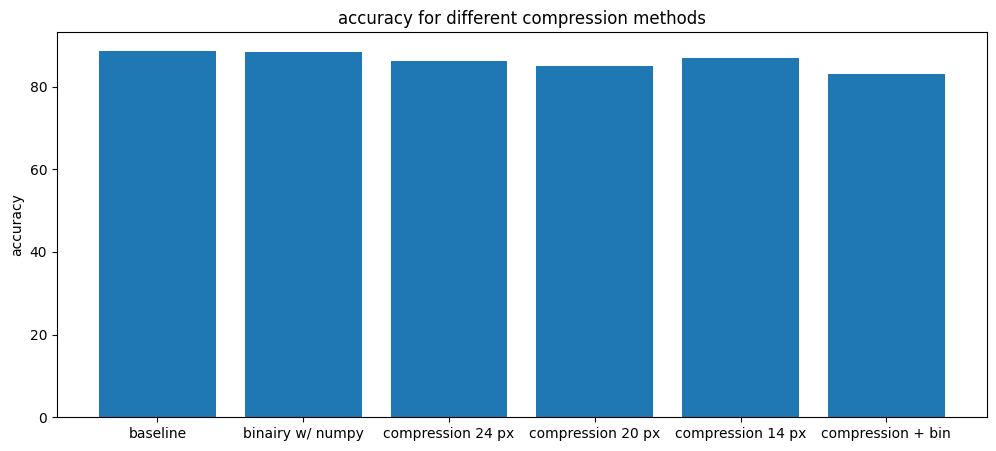

In [27]:
# results
fig, ax = plt.subplots()
encoding_techique = ['baseline',
                     'binairy w/ numpy',
                     "compression 24 px",
                     "compression 20 px",
                     "compression 14 px",
                     "compression + bin"]
counts = [
    88.7,
    88.3,
    86.2,
    85,
    87,
    83


    ]

ax.bar(encoding_techique, counts)

ax.set_ylabel('accuracy')
ax.set_title('accuracy for different compression methods')
fig.set_size_inches((12, 5))

plt.show()